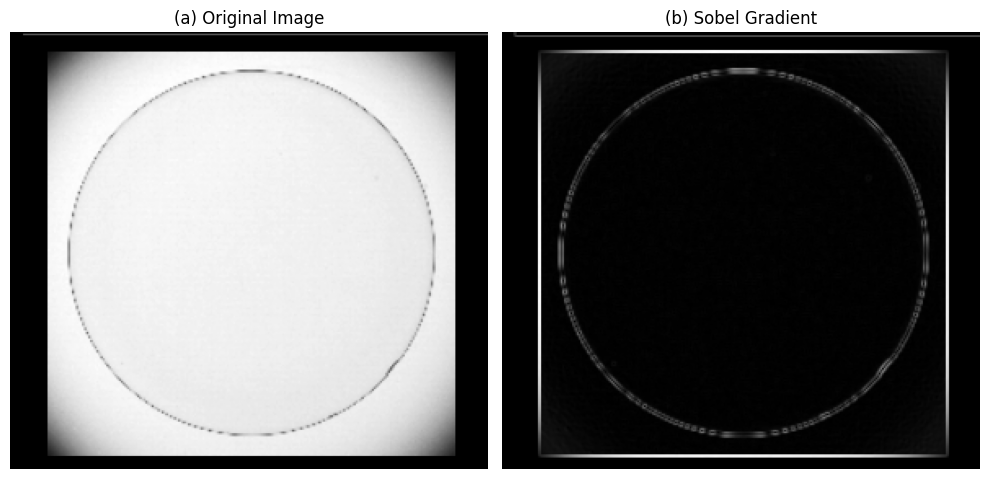

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Tạo hoặc tải ảnh đầu vào (ảnh xám)
img = cv2.imread('/content/kinhaptrong.png', cv2.IMREAD_GRAYSCALE)

# 2. Tính đạo hàm theo trục X và Y sử dụng toán tử Sobel
sobel_x = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)

# 3. Tính độ lớn Gradient (Sobel Gradient Magnitude): M(x, y) = sqrt(Gx^2 + Gy^2)
sobel_grad = cv2.magnitude(sobel_x, sobel_y)

# Chuẩn hóa về dải giá trị [0, 255] để hiển thị
sobel_grad = cv2.normalize(sobel_grad, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)

# 4. Hiển thị kết quả so sánh (a) và (b)
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title("(a) Original Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(sobel_grad, cmap='gray')
plt.title("(b) Sobel Gradient")
plt.axis('off')

plt.tight_layout()
plt.show()

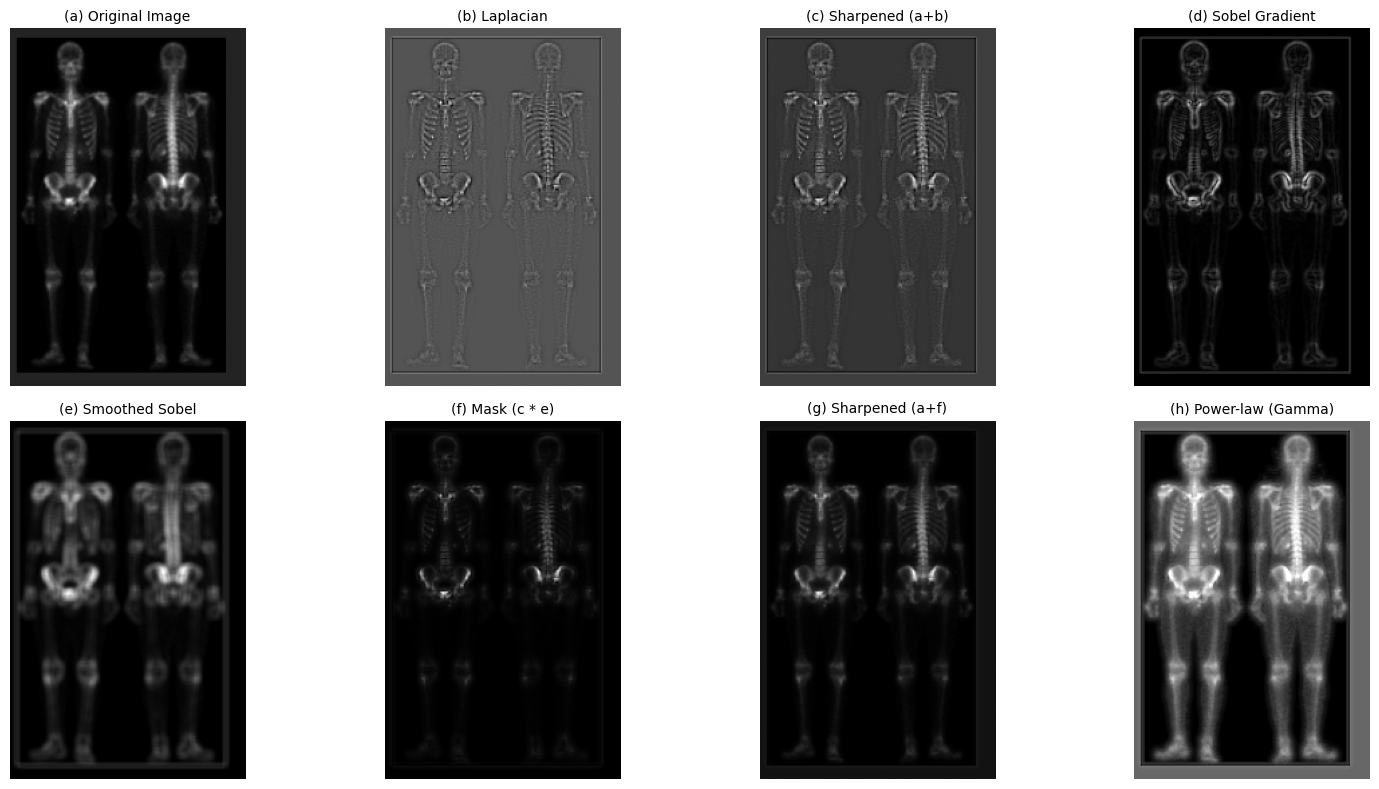

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Đọc ảnh đầu vào (a) dưới dạng ảnh xám (grayscale)
img_a = cv2.imread('/content/xuongnguoi.png', cv2.IMREAD_GRAYSCALE).astype(np.float64)

# BƯỚC 1: Laplacians & Sharpening
# (b) Laplacian của (a) sử dụng kernel 3x3
kernel_laplacian = np.array([[-1, -1, -1],
                             [-1,  8, -1],
                             [-1, -1, -1]], dtype=np.float64)
img_b = cv2.filter2D(img_a, -1, kernel_laplacian)

# (c) Ảnh sắc nét thu được từ (a) + (b)
img_c = img_a + img_b

# BƯỚC 2: Sobel & Smoothing
# (d) Sobel Gradient của (a)
sobel_x = cv2.Sobel(img_a, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(img_a, cv2.CV_64F, 0, 1, ksize=3)
img_d = np.abs(sobel_x) + np.abs(sobel_y)

# (e) Làm mịn ảnh Sobel (d) bằng bộ lọc trung bình (Averaging filter 5x5)
img_e = cv2.blur(img_d, (5, 5))

# BƯỚC 3: Masking & Combination
# (f) Tạo mặt nạ Mask bằng tích của (c) và (e)
# Chuẩn hóa giá trị về [0, 1] trước khi nhân để tránh tràn số
img_c_norm = (img_c - img_c.min()) / (img_c.max() - img_c.min() + 1e-5)
img_e_norm = (img_e - img_e.min()) / (img_e.max() - img_e.min() + 1e-5)
img_f = img_c_norm * img_e_norm

# (g) Ảnh sắc nét sắc nét hơn: cộng (a) và (f)
img_g = img_a + (img_f * 255.0)

# BƯỚC 4: Gamma Transformation
# (h) Kết quả cuối cùng áp dụng Biến đổi hàm mũ (Power-law / Gamma) lên (g)
# c = 1, gamma = 0.45 để tăng độ tương phản vùng tối
img_g_norm = np.clip(img_g / 255.0, 0, 1)
gamma = 0.45
img_h = np.power(img_g_norm, gamma) * 255.0

# HIỂN THỊ KẾT QUẢ 8 BƯỚC (a -> h)
titles = [
    '(a) Original Image', '(b) Laplacian', '(c) Sharpened (a+b)', '(d) Sobel Gradient',
    '(e) Smoothed Sobel', '(f) Mask (c * e)', '(g) Sharpened (a+f)', '(h) Power-law (Gamma)'
]
images = [img_a, img_b, img_c, img_d, img_e, img_f, img_g, img_h]

plt.figure(figsize=(16, 8))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i], fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()

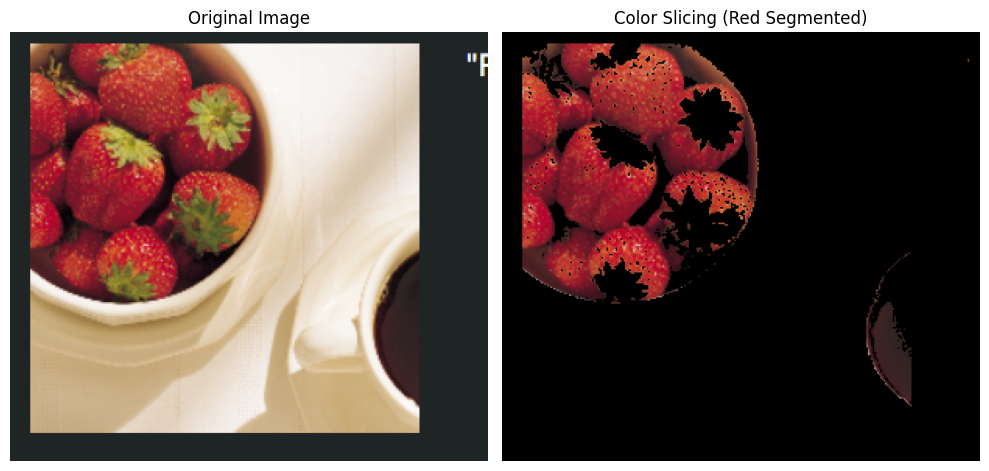

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Đọc ảnh RGB
img = cv2.imread('/content/dau.png')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# 2. Chuyển từ không gian màu RGB sang HSV
img_hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)

# 3. Định nghĩa ngưỡng màu đỏ trong không gian HSV (Màu đỏ nằm ở 2 dải Hue)
lower_red1 = np.array([0, 50, 50])
upper_red1 = np.array([10, 255, 255])

lower_red2 = np.array([170, 50, 50])
upper_red2 = np.array([180, 255, 255])

# 4. Tạo mặt nạ Mask cho màu đỏ
mask1 = cv2.inRange(img_hsv, lower_red1, upper_red1)
mask2 = cv2.inRange(img_hsv, lower_red2, upper_red2)
mask = cv2.bitwise_or(mask1, mask2)

# 5. Áp mặt nạ lên ảnh gốc (Color Slicing)
sliced_image = cv2.bitwise_and(img_rgb, img_rgb, mask=mask)

# 6. Hiển thị kết quả
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(sliced_image)
plt.title("Color Slicing (Red Segmented)")
plt.axis('off')

plt.tight_layout()
plt.show()

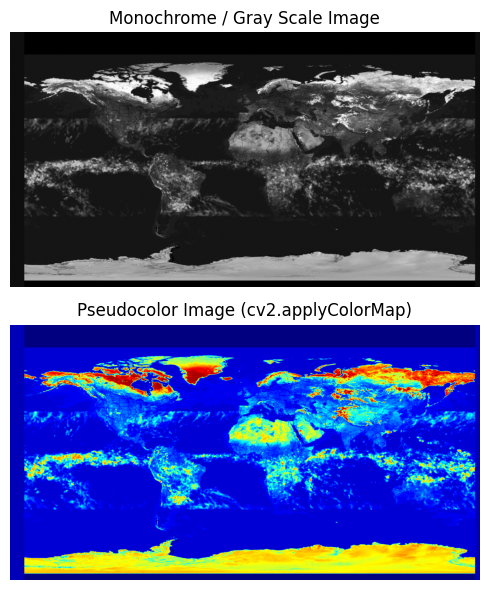

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Đọc ảnh mức xám (grayscale image)
img = cv2.imread('/content/traidat.png', cv2.IMREAD_GRAYSCALE)

# 2. Áp dụng bảng ánh xạ màu Pseudocolor (sử dụng COLORMAP_JET hoặc COLORMAP_PARULA/VIRIDIS)
img_pseudo = cv2.applyColorMap(img, cv2.COLORMAP_JET)

# Chuyển BGR (mặc định OpenCV) sang RGB để hiển thị đúng bằng Matplotlib
img_pseudo_rgb = cv2.cvtColor(img_pseudo, cv2.COLOR_BGR2RGB)

# 3. Hiển thị kết quả so sánh
plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.imshow(img, cmap='gray')
plt.title("Monochrome / Gray Scale Image")
plt.axis('off')

plt.subplot(2, 1, 2)
plt.imshow(img_pseudo_rgb)
plt.title("Pseudocolor Image (cv2.applyColorMap)")
plt.axis('off')

plt.tight_layout()
plt.show()